In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import imageio
import os
import time
from matplotlib.patches import Ellipse
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path
from UtilityNeRF import get_coarse_query_points, get_fine_query_points, render_radiance_volume, run_one_iter_of_nerf
from nivsalgorithm import select_top_views_at_iter, compute_scores_all_views
from NIVS_helper_function import entropy_only_topk,coverage_topk,union_superset,gap_stats
from entropyDegeneracy_function import detect_entropy_degeneracy, shannon_entropy_from_hist
from nerf import NerfModel

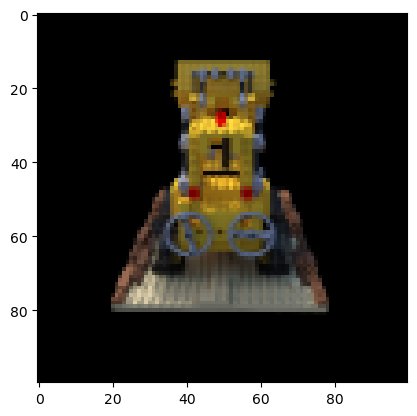

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 9458
torch.manual_seed(seed)
np.random.seed(seed)

    #  VOLUMETRIC RENDERING IN NERF - SEC:5.3
coarse_mlp = NerfModel().to(device)
fine_mlp = NerfModel().to(device)

    # Number of query points passed through the MLP at a time.
chunk_size = 512 *16 #1024 * 32

    # Number of training rays per iteration. SEC:5.3
batch_img_size = 32 #64
n_batch_pix = batch_img_size ** 2

    # INITIALIZE OPTIMIZER. SEC 5.3
lr = 5e-4
optimizer = optim.Adam(list(coarse_mlp.parameters()) + list(fine_mlp.parameters()), lr=lr)
criterion = nn.MSELoss()
    # The learning rate decays exponentially. Section 5.3
lrate_decay = 250
decay_steps = lrate_decay * 1000
decay_rate = 0.1


# Load dataset.
data_f = "tiny_nerf_data.npz"
data = np.load(data_f)

    # Set up initial ray origin (init_o) and ray directions (init_ds). These are the
    # same across samples, we just rotate them based on the orientation of the camera.
    # See Section 4.
images = data["images"]
img_size = images.shape[1]
xs = torch.arange(img_size) - (img_size / 2 - 0.5)
ys = torch.arange(img_size) - (img_size / 2 - 0.5)
(xs, ys) = torch.meshgrid(xs, -ys, indexing="xy")
focal = float(data["focal"])
pixel_coords = torch.stack([xs, ys, torch.full_like(xs, -focal)], dim=-1)
    # We want the zs to be negative ones, so we divide everything by the focal length
    # (which is in pixel units).
camera_coords = pixel_coords / focal
init_ds = camera_coords.to(device)
init_o = torch.Tensor(np.array([0, 0, 2.0])).to(device)

    # Set up test view.
test_idx = 0
plt.imshow(images[test_idx])
plt.show(block = False)
test_img = torch.Tensor(images[test_idx]).to(device)
poses = data["poses"]
test_R = torch.Tensor(poses[test_idx, :3, :3]).to(device)
test_ds = torch.einsum("ij,hwj->hwi", test_R, init_ds)
test_os = (test_R @ init_o).expand(test_ds.shape)

In [3]:
# ---- timing / table metrics ----
training_start_time = time.time()
iter_times = []                 # per-iter wall time (seconds)
eval_times = []                 # optional: time spent in eval blocks

PSNR_THRESH = 24.0              # a threshold meaningful for our dataset
iter_to_thresh = None           # first iteration that reaches PSNR_THRESH
best_psnr = -1e9

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(79, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 64])
shape of w_is: torch.Size([100, 100, 64])
Shape of sigma as the list:(235, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 192])
shape of w_is: torch.Size([100, 100, 192])
Loss: 0.1980549544095993


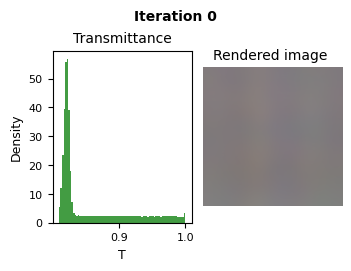

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

KeyboardInterrupt: 

In [4]:
# VOLUME RENDERING HYPER-PARAMETERS - SEC:4
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
num_fine_sample = 128
    # Bins used to sample depths along a ray. SEC:4 Eq2
"""
Here we basically  we use a stratified (arranged in layers) sampling approach 
where we partition [tn, tf ] into N evenly-spaced bins 
and then draw one sample uniformly at random from within each bin 
"""
t_i_c_gap = (t_f - t_n) / num_coarse_sample
t_i_c_bin_edges = (t_n + torch.arange(num_coarse_sample) * t_i_c_gap).to(device)

train_idxs = np.arange(len(images)) != test_idx
images = torch.Tensor(images[train_idxs])
poses = torch.Tensor(poses[train_idxs])
n_pix = img_size ** 2
pixel_ps = torch.full((n_pix,), 1 / n_pix).to(device)
psnrs = []
iternums = []
    # See Section 5.3.
num_iters = 1200
display_every = 100
coarse_mlp.train()
fine_mlp.train()
training_start_time = time.time()


mean_entropy_sigma_f = []
entropy_sigma_f =[]



for i in range(num_iters):
    t_iter0=time.time()
        # Sample image and associated pose.
    target_img_idx = np.random.randint(images.shape[0])
    target_pose = poses[target_img_idx].to(device)
    R = target_pose[:3, :3]

        # Get rotated ray origins (os) and ray directions (ds). See Section 4.
    ds = torch.einsum("ij,hwj->hwi", R, init_ds)
    os = (R @ init_o).expand(ds.shape)

        # Sample a batch of rays.
        
     ## Global illumination techniques!   
    pix_idxs = pixel_ps.multinomial(n_batch_pix, False)
    ## Why pix_idx_rows are exactly like the way they are
    pix_idx_rows = pix_idxs // img_size
    pix_idx_cols = pix_idxs % img_size
    ds_batch = ds[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )
    os_batch = os[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )

        # Run NeRF.
    (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
            ds_batch,
            num_coarse_sample,
            t_i_c_bin_edges,
            t_i_c_gap,
            os_batch,
            chunk_size,
            coarse_mlp,
            num_fine_sample,
            t_f,
            fine_mlp,
        )
    #break
    target_img = images[target_img_idx].to(device)
    target_img_batch = target_img[pix_idx_rows, pix_idx_cols].reshape(C_rs_f.shape)
        # Calculate the mean squared error for both the coarse and fine MLP models and
        # update the weights. See Equation (6) in Section 5.3.
    loss = criterion(C_rs_c, target_img_batch) + criterion(C_rs_f, target_img_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

        # Exponentially decay learning rate. See Section 5.3 and:
        # https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/.
    for g in optimizer.param_groups:
        g["lr"] = lr * decay_rate ** (i / decay_steps)

    if i % display_every == 0:
        t_eval0 = time.time()
        coarse_mlp.eval()
        fine_mlp.eval()
        with torch.no_grad():
                (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
                    test_ds,
                    num_coarse_sample,
                    t_i_c_bin_edges,
                    t_i_c_gap,
                    test_os,
                    chunk_size,
                    coarse_mlp,
                    num_fine_sample,
                    t_f,
                    fine_mlp,
                )
        loss = criterion(C_rs_f, test_img)
        print(f"Loss: {loss.item()}")
        psnr = -10.0 * torch.log10(loss)
        
        psnrs.append(psnr.item())
        iternums.append(i)

        ## Reyni's entropy
        
        # coarse and fine network weights- probabilities
            
        #w_is_f = w_is_f.detach().cpu().numpy()
        sigma_f = sigma_f.detach().cpu().numpy()
        probs_sigma_f = sigma_f/(np.sum(sigma_f, axis=2, keepdims=True)+1e-12)
        # print(f'Shape of w_is_c:{w_is_c.shape} Shape of w_is_f:{w_is_f.shape}')
        # probs_c = w_is_c/ (np.sum(w_is_c, axis=2, keepdims=True) + 1e-12) 
        # probs_f = w_is_f/ (np.sum(w_is_f, axis=2, keepdims=True) + 1e-12)
        
        

        # entropy_sigma_f = renyi_entropy_axis(probs_sigma_f, reyni_order, axis=2)

        # mean_entropy_sigma_f.append(np.mean(entropy_sigma_f))

       
        
        # plt.figure(figsize=(16, 16))
        # plt.subplot(221)
        # plt.imshow(C_rs_f.detach().cpu().numpy())
        # plt.title(f"Iteration {i}")
        # plt.axis('off')

        # plt.subplot(222)
        # plt.plot(iternums, psnrs)
        # plt.title("PSNR over Iterations")
        # plt.xlabel('Iterations')
        # plt.ylabel('PSNR (dB)')

        # plt.subplot(223)
        # plt.plot(iternums, mean_entropy_sigma_f)
        # plt.title("Mean Entropy over Iterations")
        # plt.xlabel('Iterations')
        # plt.ylabel('Mean Entropy')

        # plt.subplot(224)
        # plt.plot(mean_entropy_sigma_f, psnrs)
        # plt.title("Mean Entropy vs PSNR")
        # plt.xlabel('Mean Entropy')
        # plt.ylabel('PSNR (dB)')
        # plt.show()

        # 
        # Histogram Visualization for current iteration

        w_vals = w_is_f.detach().cpu().numpy().ravel()
        alpha_vals = alpha_f.detach().cpu().numpy().ravel()
        sigma_f = sigma_f.ravel()
        Transmittance_f = T_f.detach().cpu().numpy().ravel()

        mpl.rcParams.update({
                "font.size": 9,
                "axes.labelsize": 9,
                "axes.titlesize": 10,
                "xtick.labelsize": 8,
                "ytick.labelsize": 8,
                "legend.fontsize": 8,
                "axes.linewidth": 0.8,
            })

        fig,ax=plt.subplots(1,2,figsize=(3.4,2.6), constrained_layout= True)
        lo,hi = np.percentile(Transmittance_f,[0.5,99.5])
        ax[0].hist(Transmittance_f,bins=80,range=(lo,hi), density=True, color='forestgreen', alpha=0.85)
        ax[0].set_title('Transmittance')
        ax[0].set_xlabel('T')
        ax[0].set_ylabel('Density')

        ax[1].imshow(C_rs_f.detach().cpu().numpy())
        ax[1].set_title("Rendered image ")
        ax[1].axis("off")
        fig.suptitle(f"Iteration {i}", fontsize=10, fontweight='bold')
        #plt.savefig(f"transmittance_hist_iter_{i:05d}.pdf", bbox_inches="tight")
        plt.show()


        coarse_mlp.train() # weights get balanced for evaluation
        fine_mlp.train()

        if device == "cuda":
            torch.cuda.synchronize()
        eval_times.append(time.time() - t_eval0)

    if device == "cuda":
        torch.cuda.synchronize()

    iter_times.append(time.time() - t_iter0)
training_end_time = time.time()
total_training_time_seconds = training_end_time-training_start_time  # Replace this with your actual training time in seconds
formatted_time = time.strftime("%H:%M:%S", time.gmtime(total_training_time_seconds))
print("Completed Training!")
print(f'Total time required for training: {formatted_time}')

print("Saving model...")
torch.save(fine_mlp, "/home/ts4781/NIVS-1/Checkpoints/finalcheckpoint.pth")
print("Done!")

In [3]:
#Run this cell if you plan to extract entropy degeneracy point
#Train the NeRF after restarting the Kernel every time
entropy_Tf = []
entropy_iters = []
entropy_diff1 = []
entropy_diff2 = []
entropy_rel_change = []

In [ ]:
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
num_fine_sample = 128
    # Bins used to sample depths along a ray. SEC:4 Eq2
"""
Here we basically  we use a stratified (arranged in layers) sampling approach 
where we partition [tn, tf ] into N evenly-spaced bins 
and then draw one sample uniformly at random from within each bin 
"""
t_i_c_gap = (t_f - t_n) / num_coarse_sample
t_i_c_bin_edges = (t_n + torch.arange(num_coarse_sample) * t_i_c_gap).to(device)

train_idxs = np.arange(len(images)) != test_idx
images = torch.Tensor(images[train_idxs])
poses = torch.Tensor(poses[train_idxs])
n_pix = img_size ** 2
pixel_ps = torch.full((n_pix,), 1 / n_pix).to(device)
psnrs = []
iternums = []
# trans_entropy_vals = []
# trans_entropy_iters = []
    # See Section 5.3.
num_iters = 1800
display_every = 100
coarse_mlp.train()
fine_mlp.train()
training_start_time = time.time()


# mean_entropy_sigma_f = []
# entropy_sigma_f =[]



for i in range(num_iters):
        # Sample image and associated pose.
    target_img_idx = np.random.randint(images.shape[0])
    target_pose = poses[target_img_idx].to(device)
    R = target_pose[:3, :3]

        # Get rotated ray origins (os) and ray directions (ds). See Section 4.
    ds = torch.einsum("ij,hwj->hwi", R, init_ds)
    os = (R @ init_o).expand(ds.shape)

        # Sample a batch of rays.
        
     ## Global illumination techniques!   
    pix_idxs = pixel_ps.multinomial(n_batch_pix, False)
    ## Why pix_idx_rows are exactly like the way they are
    pix_idx_rows = pix_idxs // img_size
    pix_idx_cols = pix_idxs % img_size
    ds_batch = ds[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )
    os_batch = os[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )

        # Run NeRF.
    (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
            ds_batch,
            num_coarse_sample,
            t_i_c_bin_edges,
            t_i_c_gap,
            os_batch,
            chunk_size,
            coarse_mlp,
            num_fine_sample,
            t_f,
            fine_mlp,
        )
    #break
    target_img = images[target_img_idx].to(device)
    target_img_batch = target_img[pix_idx_rows, pix_idx_cols].reshape(C_rs_f.shape)
        # Calculate the mean squared error for both the coarse and fine MLP models and
        # update the weights. See Equation (6) in Section 5.3.
    loss = criterion(C_rs_c, target_img_batch) + criterion(C_rs_f, target_img_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

        # Exponentially decay learning rate. See Section 5.3 and:
        # https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/.
    for g in optimizer.param_groups:
        g["lr"] = lr * decay_rate ** (i / decay_steps)

    if i % display_every == 0:
        coarse_mlp.eval()
        fine_mlp.eval()
        with torch.no_grad():
                (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
                    test_ds,
                    num_coarse_sample,
                    t_i_c_bin_edges,
                    t_i_c_gap,
                    test_os,
                    chunk_size,
                    coarse_mlp,
                    num_fine_sample,
                    t_f,
                    fine_mlp,
                )
        loss = criterion(C_rs_f, test_img)
        print(f"Loss: {loss.item()}")
        psnr = -10.0 * torch.log10(loss)
        
        psnrs.append(psnr.item())
        iternums.append(i)

        ## Reyni's entropy
        
        # coarse and fine network weights- probabilities
            
        #w_is_f = w_is_f.detach().cpu().numpy()
        sigma_f = sigma_f.detach().cpu().numpy()
        probs_sigma_f = sigma_f/(np.sum(sigma_f, axis=2, keepdims=True)+1e-12)
        
        # mean_entropy_sigma_f.append(np.mean(entropy_sigma_f))

       


        # w_vals = w_is_f.detach().cpu().numpy().ravel()
        # alpha_vals = alpha_f.detach().cpu().numpy().ravel()
        sigma_f = sigma_f.ravel()
        Transmittance_f = T_f.detach().cpu().numpy().ravel()

        H_Tf,_,_ = shannon_entropy_from_hist(Transmittance_f, bins=80, value_range=(0.0,1.0))
        entropy_Tf.append(H_Tf)
        entropy_iters.append(i)
        print(f'Iter {i}: entropy = {H_Tf:.6f}')
        coarse_mlp.train() # weights get balanced for evaluation
        fine_mlp.train()
training_end_time = time.time()
total_training_time_seconds = training_end_time-training_start_time  # Replace this with your actual training time in seconds
formatted_time = time.strftime("%H:%M:%S", time.gmtime(total_training_time_seconds))
print("Completed Training!")
print(f'Total time required for training: {formatted_time}')

print("Saving model...")
torch.save(fine_mlp, "/home/ts4781/NIVS-1/Checkpoints/checkpoint1.pth")
print("Done!")



Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(79, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 64])
shape of w_is: torch.Size([100, 100, 64])
Shape of sigma as the list:(235, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 192])
shape of w_is: torch.Size([100, 100, 192])
Loss: 0.003961632493883371
Iter 0: entropy = 2.851164
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of

In [11]:
entropy_Tf

[np.float64(4.339343541975439),
 np.float64(4.2065822780718936),
 np.float64(3.6793301558650473),
 np.float64(3.5950394380716624),
 np.float64(3.467022291490699),
 np.float64(3.0890197465386526),
 np.float64(3.1218346618824553),
 np.float64(3.105024128453652),
 np.float64(2.8833762700004257),
 np.float64(3.0256851512139864)]

In [17]:
deg_result = detect_entropy_degeneracy(
    entropy_values=entropy_Tf,
    eval_iters=entropy_iters,
    tol_d1=0.01,
    tol_d2=0.5,
    tol_rel=1e-1,
    min_consecutive=1
)

print("Detected entropy degeneracy iteration:", deg_result["degeneracy_iter"])

Detected entropy degeneracy iteration: 700


Note try to restart the kernel if you need to train the NeRF, the reason is to set the NeRF at an initial stage

In [8]:
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
num_fine_sample = 128
    # Bins used to sample depths along a ray. SEC:4 Eq2
"""
Here we basically  we use a stratified (arranged in layers) sampling approach 
where we partition [tn, tf ] into N evenly-spaced bins 
and then draw one sample uniformly at random from within each bin 
"""
t_i_c_gap = (t_f - t_n) / num_coarse_sample
t_i_c_bin_edges = (t_n + torch.arange(num_coarse_sample) * t_i_c_gap).to(device)

train_idxs = np.arange(len(images)) != test_idx
images = torch.Tensor(images[train_idxs])
poses = torch.Tensor(poses[train_idxs])
n_pix = img_size ** 2
pixel_ps = torch.full((n_pix,), 1 / n_pix).to(device)
psnrs = []
iternums = []
# trans_entropy_vals = []
# trans_entropy_iters = []
    # See Section 5.3.
num_iters = 1800
display_every = 100
coarse_mlp.train()
fine_mlp.train()
training_start_time = time.time()


# mean_entropy_sigma_f = []
# entropy_sigma_f =[]



for i in range(num_iters):
        # Sample image and associated pose.
    target_img_idx = np.random.randint(images.shape[0])
    target_pose = poses[target_img_idx].to(device)
    R = target_pose[:3, :3]

        # Get rotated ray origins (os) and ray directions (ds). See Section 4.
    ds = torch.einsum("ij,hwj->hwi", R, init_ds)
    os = (R @ init_o).expand(ds.shape)

        # Sample a batch of rays.
        
     ## Global illumination techniques!   
    pix_idxs = pixel_ps.multinomial(n_batch_pix, False)
    ## Why pix_idx_rows are exactly like the way they are
    pix_idx_rows = pix_idxs // img_size
    pix_idx_cols = pix_idxs % img_size
    ds_batch = ds[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )
    os_batch = os[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )

        # Run NeRF.
    (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
            ds_batch,
            num_coarse_sample,
            t_i_c_bin_edges,
            t_i_c_gap,
            os_batch,
            chunk_size,
            coarse_mlp,
            num_fine_sample,
            t_f,
            fine_mlp,
        )
    #break
    target_img = images[target_img_idx].to(device)
    target_img_batch = target_img[pix_idx_rows, pix_idx_cols].reshape(C_rs_f.shape)
        # Calculate the mean squared error for both the coarse and fine MLP models and
        # update the weights. See Equation (6) in Section 5.3.
    loss = criterion(C_rs_c, target_img_batch) + criterion(C_rs_f, target_img_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

        # Exponentially decay learning rate. See Section 5.3 and:
        # https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/.
    for g in optimizer.param_groups:
        g["lr"] = lr * decay_rate ** (i / decay_steps)

    if i % display_every == 0:
        coarse_mlp.eval()
        fine_mlp.eval()
        with torch.no_grad():
                (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
                    test_ds,
                    num_coarse_sample,
                    t_i_c_bin_edges,
                    t_i_c_gap,
                    test_os,
                    chunk_size,
                    coarse_mlp,
                    num_fine_sample,
                    t_f,
                    fine_mlp,
                )
        loss = criterion(C_rs_f, test_img)
        print(f"Loss: {loss.item()}")
        psnr = -10.0 * torch.log10(loss)
        
        psnrs.append(psnr.item())
        iternums.append(i)

        ## Reyni's entropy
        
        # coarse and fine network weights- probabilities
            
        #w_is_f = w_is_f.detach().cpu().numpy()
        sigma_f = sigma_f.detach().cpu().numpy()
        probs_sigma_f = sigma_f/(np.sum(sigma_f, axis=2, keepdims=True)+1e-12)
        
        # mean_entropy_sigma_f.append(np.mean(entropy_sigma_f))

       


        # w_vals = w_is_f.detach().cpu().numpy().ravel()
        # alpha_vals = alpha_f.detach().cpu().numpy().ravel()
        sigma_f = sigma_f.ravel()
        Transmittance_f = T_f.detach().cpu().numpy().ravel()

        H_Tf,_,_ = shannon_entropy_from_hist(Transmittance_f, bins=80, value_range=(0.0,1.0))
        entropy_Tf.append(H_Tf)
        entropy_iters.append(i)
        print(f'Iter {i}: entropy = {H_Tf:.6f}')
        coarse_mlp.train() # weights get balanced for evaluation
        fine_mlp.train()
training_end_time = time.time()
total_training_time_seconds = training_end_time-training_start_time  # Replace this with your actual training time in seconds
formatted_time = time.strftime("%H:%M:%S", time.gmtime(total_training_time_seconds))
print("Completed Training!")
print(f'Total time required for training: {formatted_time}')

print("Saving model...")
torch.save(fine_mlp, "/home/ts4781/NIVS-1/Checkpoints/checkpoint1300.pth")
print("Done!")

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(79, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 64])
shape of w_is: torch.Size([100, 100, 64])
Shape of sigma as the list:(235, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 192])
shape of w_is: torch.Size([100, 100, 192])
Loss: 0.004007778130471706
Iter 0: entropy = 2.968876
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of

In [9]:
deg_result = detect_entropy_degeneracy(
    entropy_values=entropy_Tf,
    eval_iters=entropy_iters,
    tol_d1=0.01,
    tol_d2=0.5,
    tol_rel=1e-1,
    min_consecutive=1
)

print("Detected entropy degeneracy iteration:", deg_result["degeneracy_iter"])

Detected entropy degeneracy iteration: 200


In [10]:
training_end_time = time.time()
total_train_sec = training_end_time - training_start_time

mean_iter_ms = 1000.0 * float(np.mean(iter_times))
median_iter_ms = 1000.0 * float(np.median(iter_times))

mean_eval_ms = 1000.0 * float(np.mean(eval_times)) if len(eval_times) else float("nan")

formatted_total = time.strftime("%H:%M:%S", time.gmtime(total_train_sec))

print("Completed Training!")
print("Total training time:", formatted_total)
print(f"Mean time/iter:   {mean_iter_ms:.2f} ms (median {median_iter_ms:.2f} ms)")
print(f"Mean eval-block:  {mean_eval_ms:.2f} ms  (every {display_every} iters)")
print("Iter to reach PSNR ≥", PSNR_THRESH, ":", iter_to_thresh)
print("Best PSNR observed:", best_psnr)
print("Final PSNR logged:", psnrs[-1] if len(psnrs) else None)

Completed Training!
Total training time: 22:22:57
Mean time/iter:   367.94 ms (median 353.41 ms)
Mean eval-block:  1507.57 ms  (every 100 iters)
Iter to reach PSNR ≥ 24.0 : None
Best PSNR observed: -1000000000.0
Final PSNR logged: 26.977176666259766


Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(79, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 64])
shape of w_is: torch.Size([100, 100, 64])
Shape of sigma as the list:(235, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 192])
shape of w_is: torch.Size([100, 100, 192])
Loss: 0.11182158440351486


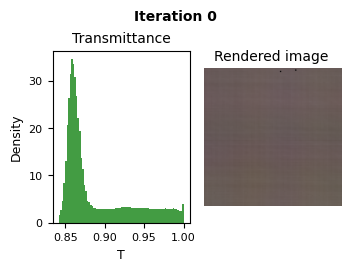

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

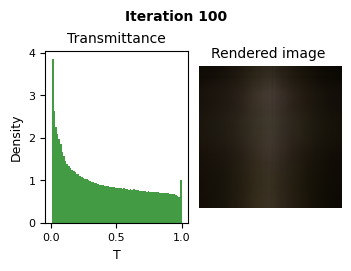

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

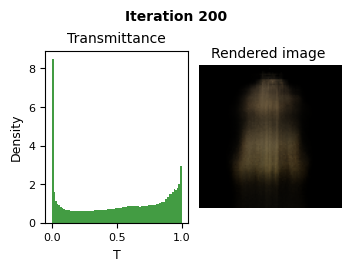

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

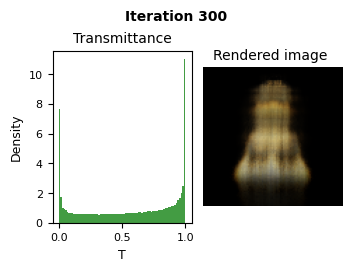

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

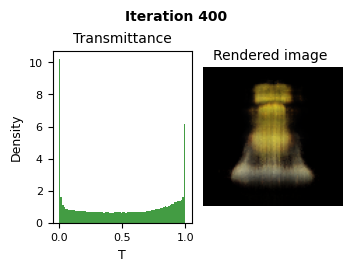

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

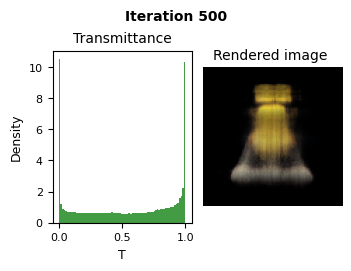

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

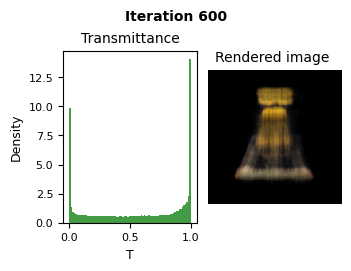

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

In [5]:
# Lets consider entropy degeneracy upto 700
# And lets train another NeRF

# Do not forget to restart the Kernel

# Save the weights until iter 700
# VOLUME RENDERING HYPER-PARAMETERS - SEC:4
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
num_fine_sample = 128
    # Bins used to sample depths along a ray. SEC:4 Eq2
"""
Here we basically  we use a stratified (arranged in layers) sampling approach 
where we partition [tn, tf ] into N evenly-spaced bins 
and then draw one sample uniformly at random from within each bin 
"""
t_i_c_gap = (t_f - t_n) / num_coarse_sample
t_i_c_bin_edges = (t_n + torch.arange(num_coarse_sample) * t_i_c_gap).to(device)

train_idxs = np.arange(len(images)) != test_idx
images = torch.Tensor(images[train_idxs])
poses = torch.Tensor(poses[train_idxs])
n_pix = img_size ** 2
pixel_ps = torch.full((n_pix,), 1 / n_pix).to(device)
psnrs = []
iternums = []
    # See Section 5.3.
num_iters = 700
display_every = 100
coarse_mlp.train()
fine_mlp.train()
training_start_time = time.time()


mean_entropy_sigma_f = []
entropy_sigma_f =[]



for i in range(num_iters):
    t_iter0=time.time()
        # Sample image and associated pose.
    target_img_idx = np.random.randint(images.shape[0])
    target_pose = poses[target_img_idx].to(device)
    R = target_pose[:3, :3]

        # Get rotated ray origins (os) and ray directions (ds). See Section 4.
    ds = torch.einsum("ij,hwj->hwi", R, init_ds)
    os = (R @ init_o).expand(ds.shape)

        # Sample a batch of rays.
        
     ## Global illumination techniques!   
    pix_idxs = pixel_ps.multinomial(n_batch_pix, False)
    ## Why pix_idx_rows are exactly like the way they are
    pix_idx_rows = pix_idxs // img_size
    pix_idx_cols = pix_idxs % img_size
    ds_batch = ds[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )
    os_batch = os[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )

        # Run NeRF.
    (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
            ds_batch,
            num_coarse_sample,
            t_i_c_bin_edges,
            t_i_c_gap,
            os_batch,
            chunk_size,
            coarse_mlp,
            num_fine_sample,
            t_f,
            fine_mlp,
        )
    #break
    target_img = images[target_img_idx].to(device)
    target_img_batch = target_img[pix_idx_rows, pix_idx_cols].reshape(C_rs_f.shape)
        # Calculate the mean squared error for both the coarse and fine MLP models and
        # update the weights. See Equation (6) in Section 5.3.
    loss = criterion(C_rs_c, target_img_batch) + criterion(C_rs_f, target_img_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

        # Exponentially decay learning rate. See Section 5.3 and:
        # https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/.
    for g in optimizer.param_groups:
        g["lr"] = lr * decay_rate ** (i / decay_steps)

    if i % display_every == 0:
        t_eval0 = time.time()
        coarse_mlp.eval()
        fine_mlp.eval()
        with torch.no_grad():
                (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
                    test_ds,
                    num_coarse_sample,
                    t_i_c_bin_edges,
                    t_i_c_gap,
                    test_os,
                    chunk_size,
                    coarse_mlp,
                    num_fine_sample,
                    t_f,
                    fine_mlp,
                )
        loss = criterion(C_rs_f, test_img)
        print(f"Loss: {loss.item()}")
        psnr = -10.0 * torch.log10(loss)
        
        psnrs.append(psnr.item())
        iternums.append(i)

        ## Reyni's entropy
        
        # coarse and fine network weights- probabilities
            
        #w_is_f = w_is_f.detach().cpu().numpy()
        sigma_f = sigma_f.detach().cpu().numpy()
        probs_sigma_f = sigma_f/(np.sum(sigma_f, axis=2, keepdims=True)+1e-12)
        # print(f'Shape of w_is_c:{w_is_c.shape} Shape of w_is_f:{w_is_f.shape}')
        # probs_c = w_is_c/ (np.sum(w_is_c, axis=2, keepdims=True) + 1e-12) 
        # probs_f = w_is_f/ (np.sum(w_is_f, axis=2, keepdims=True) + 1e-12)
        
        

        # entropy_sigma_f = renyi_entropy_axis(probs_sigma_f, reyni_order, axis=2)

        # mean_entropy_sigma_f.append(np.mean(entropy_sigma_f))

       
        
        # plt.figure(figsize=(16, 16))
        # plt.subplot(221)
        # plt.imshow(C_rs_f.detach().cpu().numpy())
        # plt.title(f"Iteration {i}")
        # plt.axis('off')

        # plt.subplot(222)
        # plt.plot(iternums, psnrs)
        # plt.title("PSNR over Iterations")
        # plt.xlabel('Iterations')
        # plt.ylabel('PSNR (dB)')

        # plt.subplot(223)
        # plt.plot(iternums, mean_entropy_sigma_f)
        # plt.title("Mean Entropy over Iterations")
        # plt.xlabel('Iterations')
        # plt.ylabel('Mean Entropy')

        # plt.subplot(224)
        # plt.plot(mean_entropy_sigma_f, psnrs)
        # plt.title("Mean Entropy vs PSNR")
        # plt.xlabel('Mean Entropy')
        # plt.ylabel('PSNR (dB)')
        # plt.show()

        # 
        # Histogram Visualization for current iteration

        w_vals = w_is_f.detach().cpu().numpy().ravel()
        alpha_vals = alpha_f.detach().cpu().numpy().ravel()
        sigma_f = sigma_f.ravel()
        Transmittance_f = T_f.detach().cpu().numpy().ravel()

        mpl.rcParams.update({
                "font.size": 9,
                "axes.labelsize": 9,
                "axes.titlesize": 10,
                "xtick.labelsize": 8,
                "ytick.labelsize": 8,
                "legend.fontsize": 8,
                "axes.linewidth": 0.8,
            })

        fig,ax=plt.subplots(1,2,figsize=(3.4,2.6), constrained_layout= True)
        lo,hi = np.percentile(Transmittance_f,[0.5,99.5])
        ax[0].hist(Transmittance_f,bins=80,range=(lo,hi), density=True, color='forestgreen', alpha=0.85)
        ax[0].set_title('Transmittance')
        ax[0].set_xlabel('T')
        ax[0].set_ylabel('Density')

        ax[1].imshow(C_rs_f.detach().cpu().numpy())
        ax[1].set_title("Rendered image ")
        ax[1].axis("off")
        fig.suptitle(f"Iteration {i}", fontsize=10, fontweight='bold')
        #plt.savefig(f"transmittance_hist_iter_{i:05d}.pdf", bbox_inches="tight")
        plt.show()


        coarse_mlp.train() # weights get balanced for evaluation
        fine_mlp.train()

        if device == "cuda":
            torch.cuda.synchronize()
        eval_times.append(time.time() - t_eval0)

    if device == "cuda":
        torch.cuda.synchronize()

    iter_times.append(time.time() - t_iter0)
training_end_time = time.time()
total_training_time_seconds = training_end_time-training_start_time  # Replace this with your actual training time in seconds
formatted_time = time.strftime("%H:%M:%S", time.gmtime(total_training_time_seconds))
print("Completed Training!")
print(f'Total time required for training: {formatted_time}')

print("Saving model...")
torch.save(fine_mlp, "/home/ts4781/NIVS-1/Checkpoints/checkpoint-700.pth")
print("Done!")


NIVS and Selected Views

In [9]:
# Load the checkpoint upto 700
chkpt_700 = torch.load("Checkpoints/checkpoint-700.pth", map_location=device,weights_only=False)


In [10]:
print(chkpt_700)

NerfModel(
  (early_mlp): Sequential(
    (0): Linear(in_features=63, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): ReLU()
  )
  (later_mlp): Sequential(
    (0): Linear(in_features=319, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
  )
  (sigma_layer): Linear(in_features=256, out_features=257, bias=True)
  (pre_final_layer): Sequential(
    (0): Linear(in_features=283, out_features=128, bias=True)
    (1): ReLU()
  )
  (final_layer): Sequential(
    (0): Linear(in_features=128, out_features=3, bias=True)
    (1): Sigmoid()
  )
)


In [12]:
print(chkpt_700.__dict__.keys())

dict_keys(['training', '_parameters', '_buffers', '_non_persistent_buffers_set', '_backward_pre_hooks', '_backward_hooks', '_is_full_backward_hook', '_forward_hooks', '_forward_hooks_with_kwargs', '_forward_hooks_always_called', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_state_dict_hooks', '_state_dict_pre_hooks', '_load_state_dict_pre_hooks', '_load_state_dict_post_hooks', '_modules', 'L_pos', 'L_dir'])


In [15]:
chkpt_700.keys()

AttributeError: 'NerfModel' object has no attribute 'keys'

In [16]:
chkpt_700.keys()

AttributeError: 'NerfModel' object has no attribute 'keys'

In [13]:
coarse_mlp.load_state_dict(chkpt_700.state_dict())



<All keys matched successfully>

In [17]:
chkpt_700.state_dict()

OrderedDict([('early_mlp.0.weight',
              tensor([[-0.0518,  0.1582,  0.0946,  ..., -0.0303,  0.0176,  0.0022],
                      [-0.0181,  0.0824,  0.1117,  ...,  0.0506, -0.1075, -0.0732],
                      [ 0.0832,  0.1033, -0.0067,  ...,  0.0296,  0.0259, -0.0190],
                      ...,
                      [ 0.0596,  0.0485,  0.1138,  ...,  0.0682, -0.0851, -0.0574],
                      [ 0.0621,  0.0159, -0.0746,  ...,  0.0712, -0.0672,  0.0235],
                      [ 0.0219, -0.0909,  0.0179,  ..., -0.0218, -0.0585,  0.0389]],
                     device='cuda:0')),
             ('early_mlp.0.bias',
              tensor([ 0.0174, -0.1004,  0.0466, -0.0740, -0.0259, -0.0433, -0.0253, -0.1039,
                      -0.0295, -0.0112, -0.0097,  0.0261,  0.0567,  0.0351, -0.0645, -0.0346,
                       0.0428,  0.0667,  0.1184,  0.0812, -0.0947, -0.0110,  0.0234,  0.0352,
                       0.0849, -0.0617, -0.0112,  0.0783, -0.0493,  0.0537, 

In [14]:
torch.__version__

'2.7.0+cu128'

In [ ]:
# We ran into trouble to save coarse and fine 
# so lets separately try to save 



In [13]:
# Apply NIVS and see what are selected views

poses_np = data["poses"]   # numpy
selected_views, scores, H_views, H_marg = select_top_views_at_iter(
    poses=poses_np,
    images=images,
    init_ds=init_ds,
    init_o=init_o,
    coarse_mlp=coarse_mlp,
    fine_mlp=fine_mlp,
    num_coarse_sample=num_coarse_sample,
    t_i_c_bin_edges=t_i_c_bin_edges,
    t_i_c_gap=t_i_c_gap,
    num_fine_sample=num_fine_sample,
    t_f=t_f,
    chunk_size=chunk_size,
    top_fraction=0.7,
    n_probe=4096,
    probe_seed=42,
    bins=60,
    opacity_thresh=0.01,
    device=device,
)

NameError: name 'run_one_iter_of_nerf' is not defined

In [4]:
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
num_fine_sample = 128
    # Bins used to sample depths along a ray. SEC:4 Eq2
"""
Here we basically  we use a stratified (arranged in layers) sampling approach 
where we partition [tn, tf ] into N evenly-spaced bins 
and then draw one sample uniformly at random from within each bin 
"""
t_i_c_gap = (t_f - t_n) / num_coarse_sample
t_i_c_bin_edges = (t_n + torch.arange(num_coarse_sample) * t_i_c_gap).to(device)

train_idxs = np.arange(len(images)) != test_idx
images = torch.Tensor(images[train_idxs])
poses = torch.Tensor(poses[train_idxs])
n_pix = img_size ** 2
pixel_ps = torch.full((n_pix,), 1 / n_pix).to(device)
psnrs = []
iternums = []
# trans_entropy_vals = []
# trans_entropy_iters = []
    # See Section 5.3.
num_iters = 700
display_every = 100
coarse_mlp.train()
fine_mlp.train()
training_start_time = time.time()


# mean_entropy_sigma_f = []
# entropy_sigma_f =[]



for i in range(num_iters):
        # Sample image and associated pose.
    target_img_idx = np.random.randint(images.shape[0])
    target_pose = poses[target_img_idx].to(device)
    R = target_pose[:3, :3]

        # Get rotated ray origins (os) and ray directions (ds). See Section 4.
    ds = torch.einsum("ij,hwj->hwi", R, init_ds)
    os = (R @ init_o).expand(ds.shape)

        # Sample a batch of rays.
        
     ## Global illumination techniques!   
    pix_idxs = pixel_ps.multinomial(n_batch_pix, False)
    ## Why pix_idx_rows are exactly like the way they are
    pix_idx_rows = pix_idxs // img_size
    pix_idx_cols = pix_idxs % img_size
    ds_batch = ds[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )
    os_batch = os[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )

        # Run NeRF.
    (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
            ds_batch,
            num_coarse_sample,
            t_i_c_bin_edges,
            t_i_c_gap,
            os_batch,
            chunk_size,
            coarse_mlp,
            num_fine_sample,
            t_f,
            fine_mlp,
        )
    #break
    target_img = images[target_img_idx].to(device)
    target_img_batch = target_img[pix_idx_rows, pix_idx_cols].reshape(C_rs_f.shape)
        # Calculate the mean squared error for both the coarse and fine MLP models and
        # update the weights. See Equation (6) in Section 5.3.
    loss = criterion(C_rs_c, target_img_batch) + criterion(C_rs_f, target_img_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

        # Exponentially decay learning rate. See Section 5.3 and:
        # https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/.
    for g in optimizer.param_groups:
        g["lr"] = lr * decay_rate ** (i / decay_steps)

    if i % display_every == 0:
        coarse_mlp.eval()
        fine_mlp.eval()
        # Save checkpoint
        checkpoint = {
        'iteration': i,
        'coarse_state_dict': coarse_mlp.state_dict(),
        'fine_state_dict': fine_mlp.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()}
    
        with torch.no_grad():
                (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
                    test_ds,
                    num_coarse_sample,
                    t_i_c_bin_edges,
                    t_i_c_gap,
                    test_os,
                    chunk_size,
                    coarse_mlp,
                    num_fine_sample,
                    t_f,
                    fine_mlp,
                )
        loss = criterion(C_rs_f, test_img)
        print(f"Loss: {loss.item()}")
        psnr = -10.0 * torch.log10(loss)
        
        psnrs.append(psnr.item())
        iternums.append(i)

        ## Reyni's entropy
        
        # coarse and fine network weights- probabilities
            
        #w_is_f = w_is_f.detach().cpu().numpy()
        sigma_f = sigma_f.detach().cpu().numpy()
        probs_sigma_f = sigma_f/(np.sum(sigma_f, axis=2, keepdims=True)+1e-12)
        
        # mean_entropy_sigma_f.append(np.mean(entropy_sigma_f))

       


        # w_vals = w_is_f.detach().cpu().numpy().ravel()
        # alpha_vals = alpha_f.detach().cpu().numpy().ravel()
        sigma_f = sigma_f.ravel()
        Transmittance_f = T_f.detach().cpu().numpy().ravel()

        H_Tf,_,_ = shannon_entropy_from_hist(Transmittance_f, bins=80, value_range=(0.0,1.0))
        entropy_Tf.append(H_Tf)
        entropy_iters.append(i)
        print(f'Iter {i}: entropy = {H_Tf:.6f}')
        coarse_mlp.train() # weights get balanced for evaluation
        fine_mlp.train()
training_end_time = time.time()
total_training_time_seconds = training_end_time-training_start_time  # Replace this with your actual training time in seconds
formatted_time = time.strftime("%H:%M:%S", time.gmtime(total_training_time_seconds))
print("Completed Training!")
print(f'Total time required for training: {formatted_time}')

print("Saving model...")
torch.save(checkpoint, "/home/ts4781/NIVS-1/Checkpoints/checkpoint-{i}.pth")
print("Done!")

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(79, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 64])
shape of w_is: torch.Size([100, 100, 64])
Shape of sigma as the list:(235, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 192])
shape of w_is: torch.Size([100, 100, 192])
Loss: 0.1980549544095993
Iter 0: entropy = 2.004478
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w

In [3]:
ckpt = torch.load("Checkpoints/checkpoint-{i}.pth", map_location=device)
coarse_mlp.load_state_dict(ckpt['coarse_state_dict'])
fine_mlp.load_state_dict(ckpt['fine_state_dict'])

<All keys matched successfully>

In [4]:
coarse_mlp.eval()
fine_mlp.eval()

NerfModel(
  (early_mlp): Sequential(
    (0): Linear(in_features=63, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): ReLU()
  )
  (later_mlp): Sequential(
    (0): Linear(in_features=319, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
  )
  (sigma_layer): Linear(in_features=256, out_features=257, bias=True)
  (pre_final_layer): Sequential(
    (0): Linear(in_features=283, out_features=128, bias=True)
    (1): ReLU()
  )
  (final_layer): Sequential(
    (0): Linear(in_features=128, out_features=3, bias=True)
    (1): Sigmoid()
  )
)

In [6]:
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
num_fine_sample = 128
    # Bins used to sample depths along a ray. SEC:4 Eq2
"""
Here we basically  we use a stratified (arranged in layers) sampling approach 
where we partition [tn, tf ] into N evenly-spaced bins 
and then draw one sample uniformly at random from within each bin 
"""
t_i_c_gap = (t_f - t_n) / num_coarse_sample
t_i_c_bin_edges = (t_n + torch.arange(num_coarse_sample) * t_i_c_gap).to(device)

In [7]:

poses_np = data["poses"]   # numpy
selected_views, scores, H_views, H_marg = select_top_views_at_iter(
    poses=poses_np,
    images=images,
    init_ds=init_ds,
    init_o=init_o,
    coarse_mlp=coarse_mlp,
    fine_mlp=fine_mlp,
    num_coarse_sample=num_coarse_sample,
    t_i_c_bin_edges=t_i_c_bin_edges,
    t_i_c_gap=t_i_c_gap,
    num_fine_sample=num_fine_sample,
    t_f=t_f,
    chunk_size=chunk_size,
    top_fraction=0.7,
    n_probe=4096,
    probe_seed=42,
    bins=60,
    opacity_thresh=0.01,
    device=device,
)

Shape of sigma as the list:(32, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 64])
shape of w_is: torch.Size([4096, 1, 64])
Shape of sigma as the list:(96, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 192])
shape of w_is: torch.Size([4096, 1, 192])
Shape of sigma as the list:(32, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 64])
shape of w_is: torch.Size([4096, 1, 64])
Shape of sigma as the list:(96, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 192])
shape of w_is: torch.Size([4096, 1, 192])
Shape of sigma as the list:(32, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 64])
shape of w_is: torch.Size([4096, 1, 64])
Shape of sigma as the list:(96, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 192])
shape of w_is: torch.Size([4096, 1, 192])
Shape of sigma as the list:(32, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 64])
shape of w_is: torch.Size([4096, 1, 64])
Shape of sigma

In [8]:

print("Selected top views:", selected_views[:20], " ... total:", len(selected_views))
print("Marginal entropy H(p):", H_marg)
print("View entropy std:", np.std(H_views))

Selected top views: [12, 11, 27, 30, 58, 47, 43, 39, 57, 61, 102, 82, 80, 77, 79, 66, 99, 100, 6, 37]  ... total: 75
Marginal entropy H(p): 1.1166661861864133
View entropy std: 0.876777671019575


In [9]:
75/106

0.7075471698113207

In [10]:
scores_all = compute_scores_all_views(torch.Tensor(images),
    torch.Tensor(poses),
    init_ds,
    init_o,
    coarse_mlp,
    fine_mlp,
    num_coarse_sample,
    t_i_c_bin_edges,
    t_i_c_gap,
    num_fine_sample,
    t_f,
    chunk_size,
    n_probe=4096,
    bins=60,
    opacity_thresh=0.01,
    device="cuda")

Shape of sigma as the list:(32, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 64])
shape of w_is: torch.Size([4096, 1, 64])
Shape of sigma as the list:(96, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 192])
shape of w_is: torch.Size([4096, 1, 192])
Shape of sigma as the list:(32, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 64])
shape of w_is: torch.Size([4096, 1, 64])
Shape of sigma as the list:(96, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 192])
shape of w_is: torch.Size([4096, 1, 192])
Shape of sigma as the list:(32, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 64])
shape of w_is: torch.Size([4096, 1, 64])
Shape of sigma as the list:(96, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 192])
shape of w_is: torch.Size([4096, 1, 192])
Shape of sigma as the list:(32, torch.Size([8192]))
Shape of sigma after:torch.Size([4096, 1, 64])
shape of w_is: torch.Size([4096, 1, 64])
Shape of sigma

In [11]:
select_views_with_coverage1 = coverage_topk(scores_all)

In [12]:
len(select_views_with_coverage1)

85

In [13]:
len(selected_views)

75

In [17]:
# Do the union of two sets selected_views_with_coverage1 and selected views

necessary_view_points = union_superset(selected_views,select_views_with_coverage1)

In [18]:
len(necessary_view_points)

86

These are the indices of images that are chosen from NIVS algorithm

In [19]:
print(necessary_view_points)

[0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 43, 44, 45, 46, 47, 48, 49, 50, 52, 54, 56, 57, 58, 59, 61, 62, 63, 65, 66, 67, 68, 70, 71, 72, 73, 74, 76, 77, 79, 80, 81, 82, 83, 84, 86, 87, 88, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 105]


Save the viewpoints such that once you restart the kernel you can still have the viewpoints

In [20]:
images.shape

(106, 100, 100, 3)

In [4]:
NIVS_viewpoints = [0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 43, 44, 45, 46, 47, 48, 49, 50, 52, 54, 56, 57, 58, 59, 61, 62, 63, 65, 66, 67, 68, 70, 71, 72, 73, 74, 76, 77, 79, 80, 81, 82, 83, 84, 86, 87, 88, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 105]

In [5]:
# Now with this necessary viewpoints images run the NeRF
images_nivs = images[NIVS_viewpoints]
images_nivs.shape




(86, 100, 100, 3)

In [6]:
poses_nivs = poses[NIVS_viewpoints]
poses_nivs.shape

(86, 4, 4)

In [8]:
# run nerf on these 86 images
images = torch.Tensor(images_nivs)
poses = torch.Tensor(poses_nivs)
#training_start_time = time.time()
iter_times = []                 # per-iter wall time (seconds)
eval_times = []                 # optional: time spent in eval blocks

PSNR_THRESH = 21.0              # a threshold meaningful for our dataset
iter_to_21 = None   
time_to_21_sec = None   

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(79, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 64])
shape of w_is: torch.Size([100, 100, 64])
Shape of sigma as the list:(235, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 192])
shape of w_is: torch.Size([100, 100, 192])
Loss: 0.19776950776576996


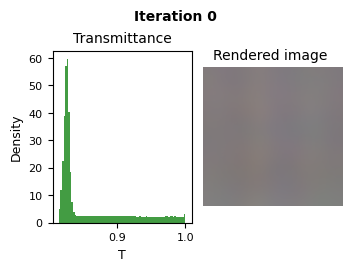

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

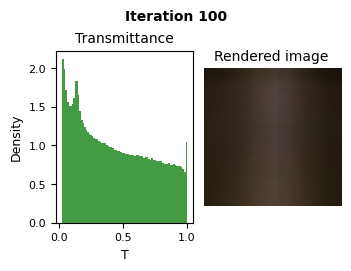

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

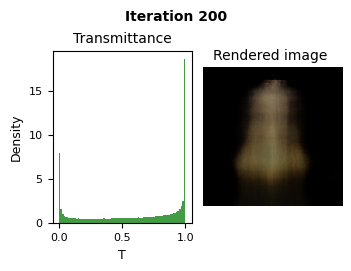

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

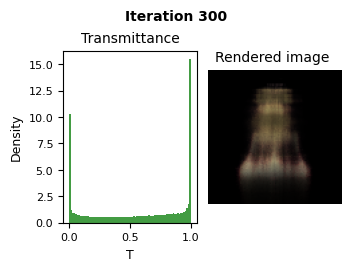

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

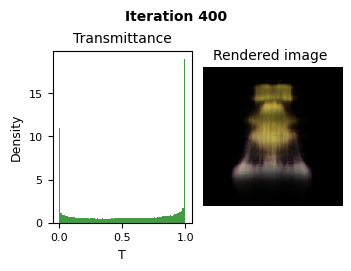

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

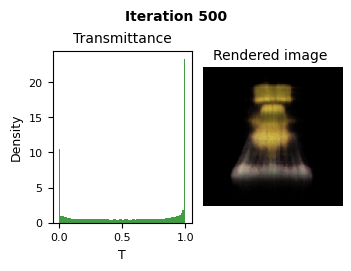

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

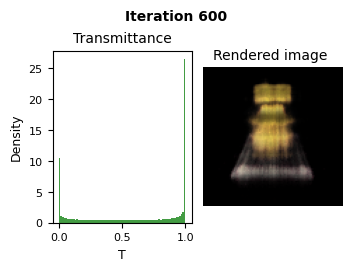

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

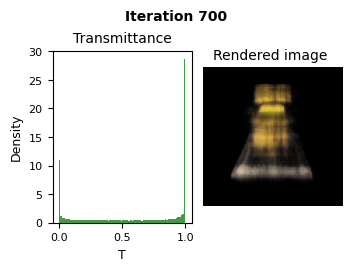

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

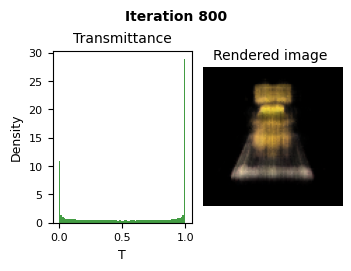

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

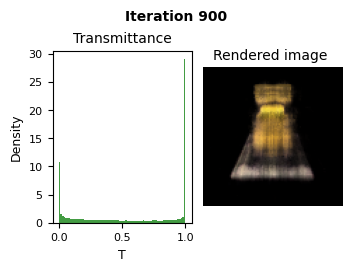

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

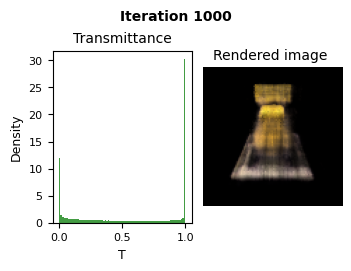

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

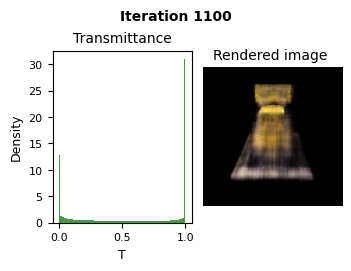

Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, 

In [9]:
# run nerf on these 86 images
images = torch.Tensor(images)
poses = torch.Tensor(poses)
#training_start_time = time.time()
iter_times = []                 # per-iter wall time (seconds)
eval_times = []                 # optional: time spent in eval blocks

PSNR_THRESH = 21.0              # a threshold meaningful for our dataset
iter_to_21 = None   
time_to_21_sec = None        # first iteration that reaches PSNR_THRESH



# VOLUME RENDERING HYPER-PARAMETERS - SEC:4
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
num_fine_sample = 128
    # Bins used to sample depths along a ray. SEC:4 Eq2
"""
Here we basically  we use a stratified (arranged in layers) sampling approach 
where we partition [tn, tf ] into N evenly-spaced bins 
and then draw one sample uniformly at random from within each bin 
"""
t_i_c_gap = (t_f - t_n) / num_coarse_sample
t_i_c_bin_edges = (t_n + torch.arange(num_coarse_sample) * t_i_c_gap).to(device)

train_idxs = np.arange(len(images)) != test_idx
images = torch.Tensor(images[train_idxs])
poses = torch.Tensor(poses[train_idxs])
n_pix = img_size ** 2
pixel_ps = torch.full((n_pix,), 1 / n_pix).to(device)
psnrs = []
iternums = []
psnr_vals = []
    # See Section 5.3.
num_iters = 1200
display_every = 100
coarse_mlp.train()
fine_mlp.train()
#training_start_time = time.time()


mean_entropy_sigma_f = []
entropy_sigma_f =[]

training_start_time = time.time()

for i in range(num_iters):
    t_iter0=time.time()
        # Sample image and associated pose.
    target_img_idx = np.random.randint(images.shape[0])
    target_pose = poses[target_img_idx].to(device)
    R = target_pose[:3, :3]

        # Get rotated ray origins (os) and ray directions (ds). See Section 4.
    ds = torch.einsum("ij,hwj->hwi", R, init_ds)
    os = (R @ init_o).expand(ds.shape)

        # Sample a batch of rays.
        
     ## Global illumination techniques!   
    pix_idxs = pixel_ps.multinomial(n_batch_pix, False)
    ## Why pix_idx_rows are exactly like the way they are
    pix_idx_rows = pix_idxs // img_size
    pix_idx_cols = pix_idxs % img_size
    ds_batch = ds[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )
    os_batch = os[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )

        # Run NeRF.
    (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
            ds_batch,
            num_coarse_sample,
            t_i_c_bin_edges,
            t_i_c_gap,
            os_batch,
            chunk_size,
            coarse_mlp,
            num_fine_sample,
            t_f,
            fine_mlp,
        )
    #break
    target_img = images[target_img_idx].to(device)
    target_img_batch = target_img[pix_idx_rows, pix_idx_cols].reshape(C_rs_f.shape)
        # Calculate the mean squared error for both the coarse and fine MLP models and
        # update the weights. See Equation (6) in Section 5.3.
    loss = criterion(C_rs_c, target_img_batch) + criterion(C_rs_f, target_img_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

        # Exponentially decay learning rate. See Section 5.3 and:
        # https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/.
    for g in optimizer.param_groups:
        g["lr"] = lr * decay_rate ** (i / decay_steps)

    if i % display_every == 0:
        t_eval0 = time.time()
        coarse_mlp.eval()
        fine_mlp.eval()
        with torch.no_grad():
                (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
                    test_ds,
                    num_coarse_sample,
                    t_i_c_bin_edges,
                    t_i_c_gap,
                    test_os,
                    chunk_size,
                    coarse_mlp,
                    num_fine_sample,
                    t_f,
                    fine_mlp,
                )
        loss = criterion(C_rs_f, test_img)
        print(f"Loss: {loss.item()}")
        psnr = -10.0 * torch.log10(loss)
        psnr_val = float(psnr.item())
        psnrs.append(psnr.item())
        psnr_vals.append(psnr_val)
        iternums.append(i)

        if np.isfinite(psnr_val):
            if iter_to_21 is None and psnr_val >= PSNR_THRESH:
                iter_to_21 = i
                time_to_21_sec = time.time() - training_start_time
        else:
            print(f"Warning: PSNR is not finite at iter {i}: {psnr_val}")
        ## Reyni's entropy
        
        # coarse and fine network weights- probabilities
            
        #w_is_f = w_is_f.detach().cpu().numpy()
        sigma_f = sigma_f.detach().cpu().numpy()
        probs_sigma_f = sigma_f/(np.sum(sigma_f, axis=2, keepdims=True)+1e-12)
        # print(f'Shape of w_is_c:{w_is_c.shape} Shape of w_is_f:{w_is_f.shape}')
        # probs_c = w_is_c/ (np.sum(w_is_c, axis=2, keepdims=True) + 1e-12) 
        # probs_f = w_is_f/ (np.sum(w_is_f, axis=2, keepdims=True) + 1e-12)
        
        

        # entropy_sigma_f = renyi_entropy_axis(probs_sigma_f, reyni_order, axis=2)

        # mean_entropy_sigma_f.append(np.mean(entropy_sigma_f))

       
        
        # plt.figure(figsize=(16, 16))
        # plt.subplot(221)
        # plt.imshow(C_rs_f.detach().cpu().numpy())
        # plt.title(f"Iteration {i}")
        # plt.axis('off')

        # plt.subplot(222)
        # plt.plot(iternums, psnrs)
        # plt.title("PSNR over Iterations")
        # plt.xlabel('Iterations')
        # plt.ylabel('PSNR (dB)')

        # plt.subplot(223)
        # plt.plot(iternums, mean_entropy_sigma_f)
        # plt.title("Mean Entropy over Iterations")
        # plt.xlabel('Iterations')
        # plt.ylabel('Mean Entropy')

        # plt.subplot(224)
        # plt.plot(mean_entropy_sigma_f, psnrs)
        # plt.title("Mean Entropy vs PSNR")
        # plt.xlabel('Mean Entropy')
        # plt.ylabel('PSNR (dB)')
        # plt.show()

        # 
        # Histogram Visualization for current iteration

        w_vals = w_is_f.detach().cpu().numpy().ravel()
        alpha_vals = alpha_f.detach().cpu().numpy().ravel()
        sigma_f = sigma_f.ravel()
        Transmittance_f = T_f.detach().cpu().numpy().ravel()

        mpl.rcParams.update({
                "font.size": 9,
                "axes.labelsize": 9,
                "axes.titlesize": 10,
                "xtick.labelsize": 8,
                "ytick.labelsize": 8,
                "legend.fontsize": 8,
                "axes.linewidth": 0.8,
            })

        fig,ax=plt.subplots(1,2,figsize=(3.4,2.6), constrained_layout= True)
        lo,hi = np.percentile(Transmittance_f,[0.5,99.5])
        ax[0].hist(Transmittance_f,bins=80,range=(lo,hi), density=True, color='forestgreen', alpha=0.85)
        ax[0].set_title('Transmittance')
        ax[0].set_xlabel('T')
        ax[0].set_ylabel('Density')

        ax[1].imshow(C_rs_f.detach().cpu().numpy())
        ax[1].set_title("Rendered image ")
        ax[1].axis("off")
        fig.suptitle(f"Iteration {i}", fontsize=10, fontweight='bold')
        plt.savefig(f"transmittance_hist_iter_{i:05d}.pdf", bbox_inches="tight")
        plt.show()


        coarse_mlp.train() # weights get balanced for evaluation
        fine_mlp.train()

        if device == "cuda":
            torch.cuda.synchronize()
        eval_times.append(time.time() - t_eval0)

    if device == "cuda":
        torch.cuda.synchronize()

    iter_times.append(time.time() - t_iter0)
training_end_time = time.time()
total_training_time_seconds = training_end_time-training_start_time  # Replace this with your actual training time in seconds
formatted_time = time.strftime("%H:%M:%S", time.gmtime(total_training_time_seconds))
print("Completed Training!")
print(f'Total time required for training: {formatted_time}')
print("Iter to reach PSNR >= 21dB:", iter_to_21)
if time_to_21_sec is not None:
    print("Time to reach 21dB:", time.strftime("%H:%M:%S", time.gmtime(time_to_21_sec)))
else:
    print("Never reached 21dB in this run.")
print("Saving model...")

print("Done!")

In [10]:
training_end_time = time.time()
total_train_sec = training_end_time - training_start_time

mean_iter_ms = 1000.0 * float(np.mean(iter_times))
median_iter_ms = 1000.0 * float(np.median(iter_times))

mean_eval_ms = 1000.0 * float(np.mean(eval_times)) if len(eval_times) else float("nan")

formatted_total = time.strftime("%H:%M:%S", time.gmtime(total_train_sec))

print("Completed Training!")
print("Total training time:", formatted_total)
print(f"Mean time/iter:   {mean_iter_ms:.2f} ms (median {median_iter_ms:.2f} ms)")
print(f"Mean eval-block:  {mean_eval_ms:.2f} ms  (every {display_every} iters)")
#print("Iter to reach PSNR ≥", PSNR_THRESH, ":", iter_to_thresh)
#print("Best PSNR observed:", best_psnr)
print("Final PSNR logged:", psnrs[-1] if len(psnrs) else None)

Completed Training!
Total training time: 00:12:03
Mean time/iter:   372.41 ms (median 356.53 ms)
Mean eval-block:  1639.30 ms  (every 100 iters)
Final PSNR logged: 23.102210998535156


At this point restart the kernel
1) Run the first compute_scores_all_views
2) Run the second cell as well as it has the basics for importing dataset and basic prelim
3) Rerun the cell that has NIVS selected NIVS_viewpoints
4) Rerun the cell to select images and poses on the necessary viewpoints

In [11]:
# With Necessary viewpoints lets see the other image quality metrics

In [9]:
import lpips
from pytorch_msssim import ssim, ms_ssim, SSIM, MS_SSIM

In [7]:
images = torch.Tensor(images_nivs)
poses = torch.Tensor(poses_nivs)

In [8]:
images.shape, poses.shape

(torch.Size([86, 100, 100, 3]), torch.Size([86, 4, 4]))

This refers to the Table 3 NeRF+NIVS part

In [10]:
# VOLUME RENDERING HYPER-PARAMETERS - SEC:4
t_n = 1.0  # Near bound.
t_f = 4.0  # Far bound.
num_coarse_sample = 64
num_fine_sample = 128
    # Bins used to sample depths along a ray. SEC:4 Eq2
"""
Here we basically  we use a stratified (arranged in layers) sampling approach 
where we partition [tn, tf ] into N evenly-spaced bins 
and then draw one sample uniformly at random from within each bin 
"""
t_i_c_gap = (t_f - t_n) / num_coarse_sample
t_i_c_bin_edges = (t_n + torch.arange(num_coarse_sample) * t_i_c_gap).to(device)

train_idxs = np.arange(len(images)) != test_idx
# images = torch.Tensor(images[train_idxs])
# poses = torch.Tensor(poses[train_idxs])
n_pix = img_size ** 2
pixel_ps = torch.full((n_pix,), 1 / n_pix).to(device)
psnrs = []
iternums = []
    # See Section 5.3.
num_iters = 1000
display_every = 100
coarse_mlp.train()
fine_mlp.train()
training_start_time = time.time()

lpips_list = []
loss_fn_alex = lpips.LPIPS(net='alex')

ssim_list = []
test_img_1 = test_img.permute(2,0,1).unsqueeze(0)
loss_fn_alex= loss_fn_alex.to(test_img_1.device)



log_file = open("metrics_log_1000.txt", "w")
log_file.write("iter,psnr,ssim,lpips,avg_error\n")


for i in range(num_iters):
        # Sample image and associated pose.
    target_img_idx = np.random.randint(images.shape[0])
    target_pose = poses[target_img_idx].to(device)
    R = target_pose[:3, :3]

        # Get rotated ray origins (os) and ray directions (ds). See Section 4.
    ds = torch.einsum("ij,hwj->hwi", R, init_ds)
    os = (R @ init_o).expand(ds.shape)

        # Sample a batch of rays.
        
     ## Global illumination techniques!   
    pix_idxs = pixel_ps.multinomial(n_batch_pix, False)
    ## Why pix_idx_rows are exactly like the way they are
    pix_idx_rows = pix_idxs // img_size
    pix_idx_cols = pix_idxs % img_size
    ds_batch = ds[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )
    os_batch = os[pix_idx_rows, pix_idx_cols].reshape(
            batch_img_size, batch_img_size, -1
        )

        # Run NeRF.
    (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
            ds_batch,
            num_coarse_sample,
            t_i_c_bin_edges,
            t_i_c_gap,
            os_batch,
            chunk_size,
            coarse_mlp,
            num_fine_sample,
            t_f,
            fine_mlp,
        )
    #break
    target_img = images[target_img_idx].to(device)
    target_img_batch = target_img[pix_idx_rows, pix_idx_cols].reshape(C_rs_f.shape)
        # Calculate the mean squared error for both the coarse and fine MLP models and
        # update the weights. See Equation (6) in Section 5.3.
    loss = criterion(C_rs_c, target_img_batch) + criterion(C_rs_f, target_img_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

        # Exponentially decay learning rate. See Section 5.3 and:
        # https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/.
    for g in optimizer.param_groups:
        g["lr"] = lr * decay_rate ** (i / decay_steps)

    if i % display_every == 0:
        coarse_mlp.eval()
        fine_mlp.eval()
        with torch.no_grad():
                (C_rs_c, C_rs_f,w_is_c, w_is_f,sigma_c, sigma_f, alpha_c, alpha_f, T_c, T_f) = run_one_iter_of_nerf(
                    test_ds,
                    num_coarse_sample,
                    t_i_c_bin_edges,
                    t_i_c_gap,
                    test_os,
                    chunk_size,
                    coarse_mlp,
                    num_fine_sample,
                    t_f,
                    fine_mlp,
                )
        loss = criterion(C_rs_f, test_img)
        print(f"Loss: {loss.item()}")
        psnr = -10.0 * torch.log10(loss)
        
        #psnrs.append(psnr.item())
        iternums.append(i)

        ## Reyni's entropy
        
        # coarse and fine network weights- probabilities
            
        w_is_f = w_is_f.detach().cpu().numpy()
        # First let's check it's a prob distribution
        print(f'shape of w_is_f: {w_is_f.shape}')

        #sigma_f = sigma_f.detach().cpu().numpy()
        #probs_sigma_f = sigma_f/(np.sum(sigma_f, axis=2, keepdims=True)+1e-12)
        # print(f'Shape of w_is_c:{w_is_c.shape} Shape of w_is_f:{w_is_f.shape}')
        # probs_c = w_is_c/ (np.sum(w_is_c, axis=2, keepdims=True) + 1e-12) 
        # probs_f = w_is_f/ (np.sum(w_is_f, axis=2, keepdims=True) + 1e-12)
        
        

        #entropy_sigma_f = renyi_entropy_axis(probs_sigma_f, reyni_order, axis=2)
        # entropy_sigma_f = entropy(w_is_f,axis=2,base=2)

        # mean_entropy_sigma_f.append(np.mean(entropy_sigma_f))

        C_rs_f_1 = C_rs_f.permute(2,0,1).unsqueeze(0)


        lpips_val = loss_fn_alex(C_rs_f_1,test_img_1)
        ssim_val = ssim(C_rs_f_1,test_img_1, data_range=255, size_average=False)
        mse_from_psnr = 10 ** (-psnr.item() / 10.0)
        avg_err = (mse_from_psnr * np.sqrt(max(0.0, 1.0 - ssim_val.item())) * lpips_val.item()) ** (1.0 / 3.0)

        print(
            f"Iter {i:04d} | "
            f"PSNR: {psnr.item():.4f} dB | "
            f"SSIM: {ssim_val.item():.4f} | "
            f"LPIPS: {lpips_val.item():.4f} | "
            f"AvgErr: {avg_err:.6f}"
        )
        log_line = f"{i},{psnr.item():.6f},{ssim_val.item():.6f},{lpips_val.item():.6f},{avg_err:.6f}"

        print(log_line)
        log_file.write(log_line + "\n")
        log_file.flush()

        psnrs.append(psnr.item())
        iternums.append(i)

        lpips_list.append(lpips_val.item())
        ssim_list.append(ssim_val.item())


       
        
        # plt.figure(figsize=(24, 24))
        # plt.subplot(221)
        # plt.imshow(C_rs_f.detach().cpu().numpy())
        # plt.title(f"Iteration {i}")
        # plt.axis('off')

        # plt.subplot(222)
        # plt.plot(mean_entropy_sigma_f, psnrs)
        # plt.title("PSNR vs Entropy")
        # plt.xlabel('Entropy')
        # plt.ylabel('PSNR (dB)')

        # plt.subplot(223)
        # plt.plot(mean_entropy_sigma_f,lpips_list)
        # plt.title("Mean Entropy vs LPIPS")
        # plt.xlabel('Mean Entropy')
        # plt.ylabel('LPIPS')

        # plt.subplot(224)
        # plt.plot(mean_entropy_sigma_f, ssim_list)
        # plt.title("Mean Entropy vs SSIM")
        # plt.xlabel('Mean Entropy')
        # plt.ylabel('SSIM')
        # plt.show()

        # 
        


        coarse_mlp.train() # weights get balanced for evaluation
        fine_mlp.train()
training_end_time = time.time()
total_training_time_seconds = training_end_time-training_start_time  # Replace this with your actual training time in seconds
formatted_time = time.strftime("%H:%M:%S", time.gmtime(total_training_time_seconds))
print("Completed Training!")
print(f'Total time required for training: {formatted_time}')

print("Saving model...")
#torch.save(fine_mlp, "/home/ts4781/StatisticalAnalysis_RF/ReynisEntropy/finalcheckpoint.pth")
print("Done!")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/ts4781/anaconda/envs/pytorch_env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ts4781/anaconda/envs/pytorch_env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/ts4781/anaconda/envs/pytorch_env/lib/python3.9/site-packages/lpips/weights/v0.1/alex.pth
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of sigma as the list:(24, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 192])
shape of w_is: torch.Size([32, 32, 192])
Shape of sigma as the list:(79, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 64])
shape of w_is: torch.Size([100, 100, 64])
Shape of sigma as the list:(235, torch.Size([8192]))
Shape of sigma after:torch.Size([100, 100, 192])
shape of w_is: torch.Size([100, 100, 192])
Loss: 0.19812901318073273
shape of w_is_f: (100, 100, 192)
Iter 0000 | PSNR: 7.0305 dB | SSIM: 0.9730 | LPIPS: 0.6894 | AvgErr: 0.282050
0,7.030519,0.973012,0.689355,0.282050
Shape of sigma as the list:(8, torch.Size([8192]))
Shape of sigma after:torch.Size([32, 32, 64])
shape of w_is: torch.Size([32, 32, 64])
Shape of 